# Word Embedding-Based Model for Mental Health Text Classification

In this notebook, we implement a **neural embedding–based approach** to classify mental-health related text across seven categories.  
Our chosen architecture is:

## Word2Vec Embeddings + LSTM Network

**Word2Vec** learns dense vector representations of words based on their surrounding context, placing semantically similar words close together in vector space.  
This allows the model to capture meaning beyond exact word matches and understand subtle variations in mental-health expressions.

The **LSTM (Long Short-Term Memory)** network processes text as an ordered sequence, enabling it to model emotional flow, contextual dependencies, and negations within user statements.  
By retaining information over long sequences, the LSTM provides deeper contextual understanding compared to traditional frequency-based models.


This notebook evaluates how a context-aware neural architecture performs on the mental-health classification task, serving as a bridge between traditional word-based models and the transformer-based approaches explored later in the project.


In [1]:
# Imports & basic config

import os
import random

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Load cleaned dataset

DATA_PATH = "/kaggle/input/dataset/sentiment_mental_health_clean.csv"

df = pd.read_csv(DATA_PATH)

print("Data shape:", df.shape)
df.head()


Data shape: (50988, 2)


,statement,status
0,oh my gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,all wrong back off dear forward doubt stay in ...,Anxiety
3,i ve shifted my focus to something else but i ...,Anxiety
4,i m restless and restless it s been a month no...,Anxiety


We load the cleaned mental-health dataset from storage and display its shape and first few rows. This ensures the file was read correctly and gives us a quick preview of the `statement` text and its corresponding `status` label before continuing with preprocessing.


In [3]:
# Basic sanity checks

print("Columns:", df.columns.tolist(), "\n")

# Quick look at label distribution
print("Label distribution (status):")
print(df["status"].value_counts(), "\n")

Columns: ['statement', 'status'] 

Label distribution (status):
status
Normal                  15960
Depression              15090
Suicidal                10638
Anxiety                  3614
Bipolar                  2501
Stress                   2291
Personality disorder      894
Name: count, dtype: int64 



In [4]:
# Text length summary

text_lengths = df["statement"].astype(str).str.split().str.len()

print(text_lengths.describe())

count    50988.000000
mean       114.757845
std        166.432349
min          1.000000
25%         16.000000
50%         63.000000
75%        150.000000
max       6300.000000
Name: statement, dtype: float64


Now, we prepare the labels and dataset splits required for model training. We first convert each mental-health category into a numeric ID, and then create stratified train, validation, and test splits to preserve the original class distribution across all sets.


In [5]:
# Encode labels (status -> integer IDs)

# Get unique labels in a stable order
unique_labels = sorted(df["status"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label mapping (status -> id):")
for k, v in label2id.items():
    print(f"{k:20s} -> {v}")

# Add an integer label column
df["label_id"] = df["status"].map(label2id)

df[["statement", "status", "label_id"]].head()


Label mapping (status -> id):
Anxiety              -> 0
Bipolar              -> 1
Depression           -> 2
Normal               -> 3
Personality disorder -> 4
Stress               -> 5
Suicidal             -> 6


,statement,status,label_id
0,oh my gosh,Anxiety,0
1,trouble sleeping confused mind restless heart ...,Anxiety,0
2,all wrong back off dear forward doubt stay in ...,Anxiety,0
3,i ve shifted my focus to something else but i ...,Anxiety,0
4,i m restless and restless it s been a month no...,Anxiety,0


In [6]:
# Stratified train/val/test split

TEST_SIZE = 0.15   # 15% test
VAL_SIZE  = 0.15   # 15% validation

# First split off the test set from the full data
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label_id"]
)

# Now split train_val into train and val
# desired val fraction relative to train_val:
val_relative = VAL_SIZE / (1.0 - TEST_SIZE)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative,
    random_state=SEED,
    stratify=train_val_df["label_id"]
)

print("Total:", df.shape)
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)


Total: (50988, 3)
Train: (35690, 3)
Val  : (7649, 3)
Test : (7649, 3)


In [7]:
# Reset index for cleanliness and quick peek

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train sample:")
display(train_df.head())

print("Validation sample:")
display(val_df.head())

print("Test sample:")
display(test_df.head())

Train sample:


,statement,status,label_id
0,i had a plan a date and a note typed up me and...,Suicidal,6
1,i want to commit suicide already i have been s...,Depression,2
2,it s hard when loved ones don t understand avp...,Personality disorder,4
3,does anyone else constantly think about the fa...,Bipolar,1
4,i have blocked everyone that ever cared about ...,Suicidal,6


Validation sample:


,statement,status,label_id
0,masha allah i been dey wait make someone tweet...,Depression,2
1,you guys want to take the vaccine if you want ...,Normal,3
2,ehun and kai often wear sleeveless shirts,Normal,3
3,the last 2 months have been extremely bad in m...,Depression,2
4,allah knows you are strong that s why the test...,Normal,3


Test sample:


,statement,status,label_id
0,intrusive thoughts about past mistakes i m 23 ...,Anxiety,0
1,regretting a cbt challenge erp exposure so i h...,Anxiety,0
2,i hate myself,Depression,2
3,how can i painlessly kill myself,Suicidal,6
4,kaschua no just didn t know if you thought put...,Normal,3


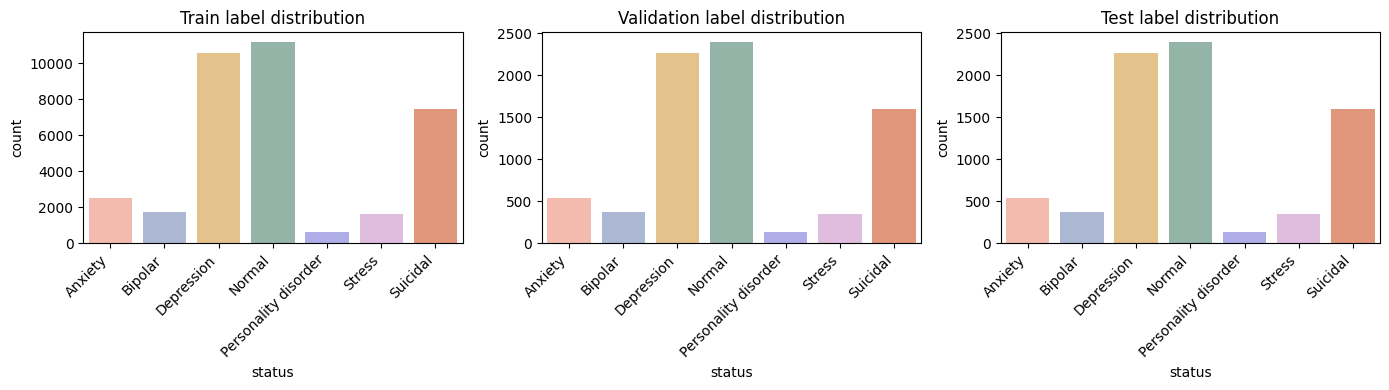

In [8]:
# Visualize label distributions with custom colors

import matplotlib.pyplot as plt
import seaborn as sns

# Custom color mapping
status_colors = {
    "Normal":               "#8FB9A8", 
    "Depression":           "#F2C57C",  
    "Suicidal":             "#F28F6B", 
    "Anxiety":              "#FFB4A2",  
    "Bipolar":              "#A5B5D9", 
    "Stress":               "#E4B7E5",  
    "Personality disorder": "#A4A3F1"
}

palette = [status_colors[label] for label in unique_labels]

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.countplot(
    data=train_df,
    x="status",
    order=unique_labels,
    palette=palette
)
plt.title("Train label distribution")
plt.xticks(rotation=45, ha="right")

plt.subplot(1, 3, 2)
sns.countplot(
    data=val_df,
    x="status",
    order=unique_labels,
    palette=palette
)
plt.title("Validation label distribution")
plt.xticks(rotation=45, ha="right")

plt.subplot(1, 3, 3)
sns.countplot(
    data=test_df,
    x="status",
    order=unique_labels,
    palette=palette
)
plt.title("Test label distribution")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


These plots confirm that the stratified splitting preserved the original class distribution across the train, validation, and test sets, ensuring balanced representation for all seven categories.


We prepare the text for neural modeling by tokenizing each statement, building a vocabulary from the training split, and converting words into integer IDs. We visualize the most frequent tokens to understand dataset characteristics, and finally transform all texts into fixed-length padded sequences that can be fed into the Word2Vec embedding layer and LSTM network.


In [9]:
# Tokenizer and tokenized text for train/val/test

def tokenize(text):
    """
    tokenizer: lowercases (already should be),
    splits on whitespace, and strips extra spaces.
    """
    if not isinstance(text, str):
        text = str(text)
    return text.strip().split()

# Apply tokenizer to each split
train_tokens = train_df["statement"].astype(str).apply(tokenize)
val_tokens   = val_df["statement"].astype(str).apply(tokenize)
test_tokens  = test_df["statement"].astype(str).apply(tokenize)

print("Example tokenized train statement:")
print(train_df["statement"].iloc[1])
print(train_tokens.iloc[1])

Example tokenized train statement:
i want to commit suicide already i have been stuck in a toxic abusive family for 6 years and a family member just committed a criminal act on me i have decided not to pursue my case but things have been going so bad i cannot leave my house because my bank passcode and passport are with my family i want to die i really cannot take this anymore life at a crisis shelter or foster family looks bleak to me cos i seldom hear of happy stories after children are transferred to foster or crisis places please let me die i want to kill myself
['i', 'want', 'to', 'commit', 'suicide', 'already', 'i', 'have', 'been', 'stuck', 'in', 'a', 'toxic', 'abusive', 'family', 'for', '6', 'years', 'and', 'a', 'family', 'member', 'just', 'committed', 'a', 'criminal', 'act', 'on', 'me', 'i', 'have', 'decided', 'not', 'to', 'pursue', 'my', 'case', 'but', 'things', 'have', 'been', 'going', 'so', 'bad', 'i', 'cannot', 'leave', 'my', 'house', 'because', 'my', 'bank', 'passcode', 'a

In [10]:
MAX_LEN = 200

In [11]:
# Build vocabulary from training tokens only

from collections import Counter

# Count word frequencies in training data
word_counter = Counter()
for tokens in train_tokens:
    word_counter.update(tokens)

print(f"Total unique tokens in train: {len(word_counter)}")

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Start vocab with special tokens
word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

# Add remaining words
for word in word_counter.keys():
    if word not in word2idx:
        word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(word2idx)
print(f"Final vocab size (including PAD/UNK): {vocab_size}")


Total unique tokens in train: 47927
Final vocab size (including PAD/UNK): 47929


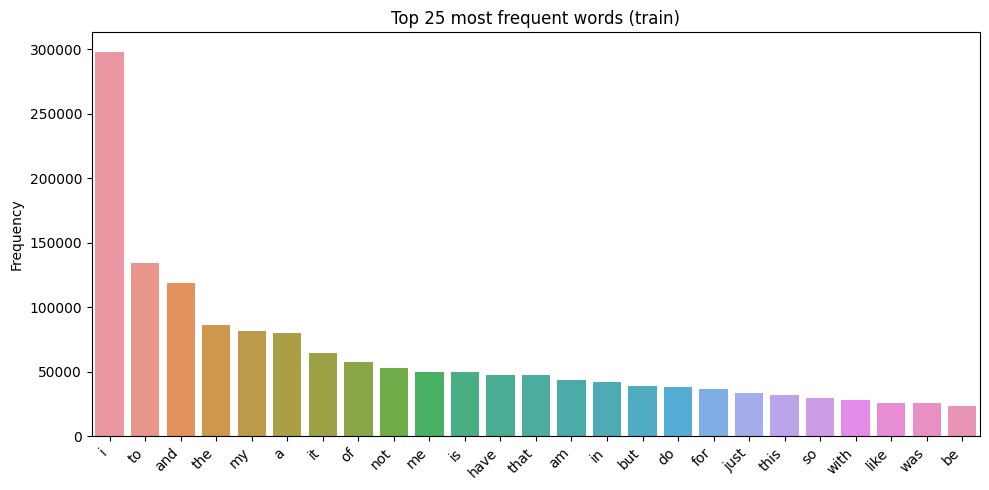

In [12]:
# Visualize top frequent words in train

import seaborn as sns
import matplotlib.pyplot as plt

TOP_N = 25
most_common_words = word_counter.most_common(TOP_N)
words, freqs = zip(*most_common_words)

plt.figure(figsize=(10, 5))
sns.barplot(x=np.array(words), y=list(freqs))
plt.title(f"Top {TOP_N} most frequent words (train)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [13]:
# Convert tokens to padded integer sequences

import numpy as np

def encode_and_pad(tokens, word2idx, max_len):
    """
    Convert a list of tokens to a list of indices and pad/truncate to max_len.
    """
    ids = []
    for tok in tokens:
        ids.append(word2idx.get(tok, word2idx[UNK_TOKEN]))
    # Truncate
    ids = ids[:max_len]
    # Pad
    if len(ids) < max_len:
        ids = ids + [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    return ids

# Apply to each split
X_train = np.array([encode_and_pad(toks, word2idx, MAX_LEN) for toks in train_tokens])
X_val   = np.array([encode_and_pad(toks, word2idx, MAX_LEN) for toks in val_tokens])
X_test  = np.array([encode_and_pad(toks, word2idx, MAX_LEN) for toks in test_tokens])

y_train = train_df["label_id"].values
y_val   = val_df["label_id"].values
y_test  = test_df["label_id"].values

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)


X_train shape: (35690, 200)
X_val shape  : (7649, 200)
X_test shape : (7649, 200)
y_val shape  : (7649,)
y_test shape : (7649,)


In this step, we train a Word2Vec model on the tokenized training sentences and use it to initialize the embedding layer for our LSTM. We first build a corpus of token lists, learn dense word vectors with skip-gram Word2Vec, then construct an embedding matrix where each vocabulary index is mapped to its corresponding Word2Vec vector (or a random vector if unseen). Finally, we convert this matrix to a PyTorch tensor so it can be plugged directly into the neural network.


In [14]:
# Import Word2Vec and prepare corpus (list-of-lists)

from gensim.models import Word2Vec

# Corpus for Word2Vec -> ONLY train set (to avoid leakage)
corpus = train_tokens.tolist()

print("Number of training sentences:", len(corpus))
print("Example tokenized sentence:", corpus[0][:20])


Number of training sentences: 35690
Example tokenized sentence: ['i', 'had', 'a', 'plan', 'a', 'date', 'and', 'a', 'note', 'typed', 'up', 'me', 'and', 'my', 'family', 'are', 'moving', 'across', 'the', 'country']


In [15]:
# Train Word2Vec model

EMBED_DIM = 300          
WINDOW_SIZE = 5          # context window
MIN_COUNT = 2            # ignore extremely rare words
SG = 1                   # 0 = CBOW, 1 = Skip-gram

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=EMBED_DIM,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    workers=4,      
    sg=SG
)

print("Word2Vec training complete.")
print("Vocabulary size inside Word2Vec:", len(w2v_model.wv))


Word2Vec training complete.
Vocabulary size inside Word2Vec: 23832


In [16]:
# Build embedding matrix

import numpy as np

vocab_size = len(word2idx)

# Initialize embedding matrix with random vectors
embedding_matrix = np.random.uniform(
    low=-0.05, high=0.05, size=(vocab_size, EMBED_DIM)
).astype(np.float32)

# Replace vectors for words present in Word2Vec
found = 0
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1

print(f"Found pretrained vectors for {found}/{vocab_size} words.")


Found pretrained vectors for 23832/47929 words.


In [17]:
# Convert embedding matrix to a PyTorch tensor

import torch

embedding_matrix_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

print("Embedding matrix tensor shape:", embedding_matrix_tensor.shape)

Embedding matrix tensor shape: torch.Size([47929, 300])


In [18]:
# Try some similarity checks

test_words = ["anxiety", "depression", "sad", "suicidal", "worried"]

for w in test_words:
    if w in w2v_model.wv:
        print(f"\nTop words similar to '{w}':")
        for sim, score in w2v_model.wv.most_similar(w, topn=5):
            print(f"   {sim}: {score:.3f}")
    else:
        print(f"\nWord '{w}' not in Word2Vec vocabulary.")



Top words similar to 'anxiety':
   phobia: 0.671
   agoraphobia: 0.651
   worsening: 0.644
   asthma: 0.641
   crippling: 0.637

Top words similar to 'depression':
   gad: 0.607
   mdd: 0.598
   depressive: 0.594
   ocd: 0.592
   generalized: 0.583

Top words similar to 'sad':
   resentful: 0.671
   conflicted: 0.659
   horny: 0.654
   lonely: 0.650
   heartbroken: 0.647

Top words similar to 'suicidal':
   ideation: 0.730
   ideations: 0.662
   homicidal: 0.659
   intrusive: 0.639
   selfharm: 0.639

Top words similar to 'worried':
   concerned: 0.720
   paranoid: 0.670
   nervous: 0.642
   lymphoma: 0.634
   worrying: 0.631


These similarity checks give us a quick qualitative look at the learned Word2Vec embeddings. Words like *anxiety*, *depression*, and *suicidal* return semantically meaningful neighbors, indicating that the model has captured useful relationships between mental-health related terms.

This section prepares the processed text and labels for use in PyTorch by wrapping them in a custom `Dataset` class. The class exposes each sample as a pair of tensors—one containing the padded token sequence and the other containing the corresponding label—making the data compatible with neural network training.

After defining the dataset structure, separate dataset objects are created for the training, validation, and test splits. These are passed into PyTorch `DataLoader`s, which handle batching, shuffling, and efficient iteration during training and evaluation. By organizing the data into consistent mini-batches, the model can be trained more efficiently and with better memory management.


In [19]:
# Custom PyTorch Dataset for classification

from torch.utils.data import Dataset

class MentalHealthDataset(Dataset):
    def __init__(self, X, y):
        """
        X: numpy array of shape (num_samples, MAX_LEN)
        y: numpy array of integer class labels
        """
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        input_ids = torch.tensor(self.X[idx], dtype=torch.long)
        label = torch.tensor(self.y[idx], dtype=torch.long)   # CrossEntropy -> long
        
        return input_ids, label


In [20]:
# Instantiate PyTorch Dataset objects

train_dataset = MentalHealthDataset(X_train, y_train)
val_dataset   = MentalHealthDataset(X_val, y_val)
test_dataset  = MentalHealthDataset(X_test, y_test)

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))

Train samples: 35690
Val samples  : 7649
Test samples : 7649


In [21]:
# Create DataLoaders

from torch.utils.data import DataLoader

BATCH_SIZE = 64  

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

print("Train loader batches:", len(train_loader))
print("Val loader batches  :", len(val_loader))
print("Test loader batches :", len(test_loader))

Train loader batches: 558
Val loader batches  : 120
Test loader batches : 120


In [22]:
# Step 5.4: Inspect shapes from a batch

sample_inputs, sample_labels = next(iter(train_loader))

print("Input batch shape :", sample_inputs.shape)   # (batch_size, MAX_LEN)
print("Labels batch shape:", sample_labels.shape)   # (batch_size)

print("\nExample input_ids:", sample_inputs[0][:20])
print("Example label:", sample_labels[0].item())


Input batch shape : torch.Size([64, 200])
Labels batch shape: torch.Size([64])

Example input_ids: tensor([    2,    83,     4,  2463,  3390,   354,    31,    12,  4704,   563,
        10302,     7,   393,    31,    12,  4704,   563,   483,     2,  3398])
Example label: 0


This section defines the neural architecture used for classification and configures the components required for training. The model is built around a single-layer LSTM that processes sequences of Word2Vec-initialized embeddings. The embedding layer is loaded with the pretrained matrix created earlier, giving the network access to semantically meaningful word vectors from the start.

Inside the model, each input sentence is passed through the embedding layer and then through the LSTM encoder, which captures contextual and sequential dependencies across the tokens. Instead of relying solely on the final hidden state, the network applies max-pooling across all time steps to extract the most informative features from the entire sequence. This pooled representation is then fed through a dropout layer for regularization and a fully connected layer that outputs logits for the seven mental-health categories.

After defining the model, the code initializes it with the chosen hyperparameters, transfers it to the computation device, and prepares the loss function and optimizer. A class-weighted cross-entropy loss is used to counter the dataset’s label imbalance, ensuring minority classes contribute more to the gradient updates. The Adam optimizer is then instantiated to update the model parameters efficiently during training.


In [23]:
# Define the LSTM classifier model

import torch.nn as nn
import torch.nn.functional as F

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim=128,
        num_classes=7,
        dropout=0.3
    ):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        # 1) Embedding layer initialized from Word2Vec
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False   # fine-tune embeddings
        )

        # 2) Single-layer LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # 3) Dropout
        self.dropout = nn.Dropout(dropout)

        # 4) Final linear layer (7 logits)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)        # (batch, seq_len, embed_dim)
        output, (h_n, c_n) = self.lstm(emb)
        
        # # h_n: final hidden state of shape (num_layers, batch, hidden_dim)
        # h_last = h_n[-1]               # (batch, hidden_dim)

        # out = self.dropout(h_last)

        # output shape = (batch, seq_len, hidden_dim)
        # Apply max-pooling over sequence dimension
        pooled, _ = torch.max(output, dim=1)   # (batch, hidden_dim)
        
        out = self.dropout(pooled)
        
        logits = self.fc(out)

        return logits                  # CrossEntropyLoss expects raw logits


In [24]:
# Create model, optimizer, loss function

from sklearn.utils.class_weight import compute_class_weight

HIDDEN_DIM = 128
# HIDDEN_DIM = 256
NUM_CLASSES = len(unique_labels)   # = 7
DROPOUT = 0.3
# DROPOUT = 0.5

model = LSTMClassifier(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

model = model.to(device)

# criterion = nn.CrossEntropyLoss()
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

LSTMClassifier(
  (embedding): Embedding(47929, 300)
  (lstm): LSTM(300, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=7, bias=True)
)


Now we implements the training and evaluation logic for the LSTM classifier. First, a helper function computes the macro F1 score so that performance can be measured fairly across all seven classes, regardless of class imbalance. 
Next, a validation routine runs the model on the validation set without gradient updates, accumulating loss and predictions in order to report both average validation loss and macro F1 at the end of each epoch. 
Finally, the main training loop iterates over the training data for a fixed number of epochs: for each batch it performs a forward pass, computes the weighted cross-entropy loss, backpropagates gradients, and updates the model parameters with Adam. 

After every epoch, the loop evaluates the model on the validation set, tracks the history of train/validation loss and F1, and saves a checkpoint whenever a new best macro F1 score is achieved.


In [25]:
# Macro F1 calculation helper

from sklearn.metrics import f1_score

def compute_macro_f1(y_true, y_pred):
    """
    y_true: numpy array (N,)
    y_pred: numpy array (N,)
    """
    return f1_score(y_true, y_pred, average="macro")

In [26]:
# Validation loop

def evaluate(model, val_loader, criterion):
    model.eval()

    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = val_loss / len(val_loader)
    macro_f1 = compute_macro_f1(all_labels, all_preds)

    return avg_loss, macro_f1

In [27]:
# Training loop with validation + tracking metrics

EPOCHS = 10

train_losses = []
val_losses = []
val_f1_scores = []

best_val_loss = float("inf")
best_model_path = "best_lstm_model.pt"
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Training loss for this epoch
    avg_train_loss = running_loss / len(train_loader)

    # Validation
    avg_val_loss, macro_f1 = evaluate(model, val_loader, criterion)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_f1_scores.append(macro_f1)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Macro F1: {macro_f1:.4f}")

    # Save best model based on val loss
    # if avg_val_loss < best_val_loss:
    #     best_val_loss = avg_val_loss
    #     torch.save(model.state_dict(), best_model_path)
    #     print("  -> Saved as best model")

    # Save best model based on macro f1 score
    if macro_f1 > best_val_f1:
        best_val_f1 = macro_f1
        torch.save(model.state_dict(), best_model_path)
        print("  -> Saved as best model (best F1)")


print("\nTraining complete.")


Epoch 1/10
  Train Loss: 1.1926
  Val Loss:   0.8969
  Val Macro F1: 0.6266
  -> Saved as best model (best F1)
Epoch 2/10
  Train Loss: 0.7618
  Val Loss:   0.7196
  Val Macro F1: 0.6776
  -> Saved as best model (best F1)
Epoch 3/10
  Train Loss: 0.5961
  Val Loss:   0.6842
  Val Macro F1: 0.6934
  -> Saved as best model (best F1)
Epoch 4/10
  Train Loss: 0.4502
  Val Loss:   0.7041
  Val Macro F1: 0.6848
Epoch 5/10
  Train Loss: 0.3386
  Val Loss:   0.7475
  Val Macro F1: 0.6888
Epoch 6/10
  Train Loss: 0.2589
  Val Loss:   0.8610
  Val Macro F1: 0.6923
Epoch 7/10
  Train Loss: 0.2017
  Val Loss:   0.9194
  Val Macro F1: 0.6845
Epoch 8/10
  Train Loss: 0.1523
  Val Loss:   1.1199
  Val Macro F1: 0.6917
Epoch 9/10
  Train Loss: 0.1265
  Val Loss:   1.1320
  Val Macro F1: 0.6760
Epoch 10/10
  Train Loss: 0.1009
  Val Loss:   1.3578
  Val Macro F1: 0.6662

Training complete.


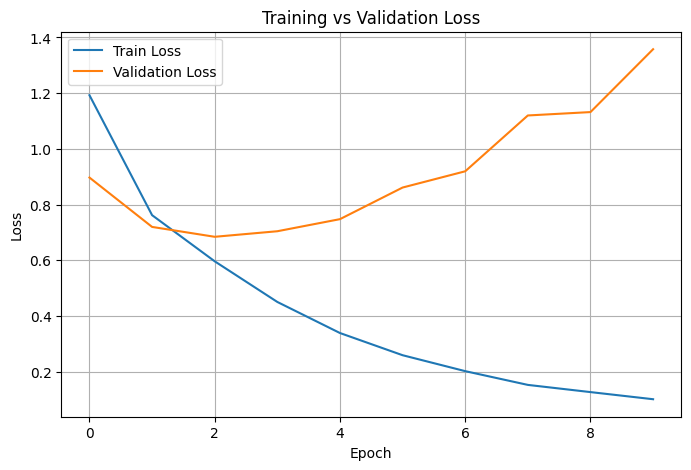

In [28]:
# Visualize Training vs Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


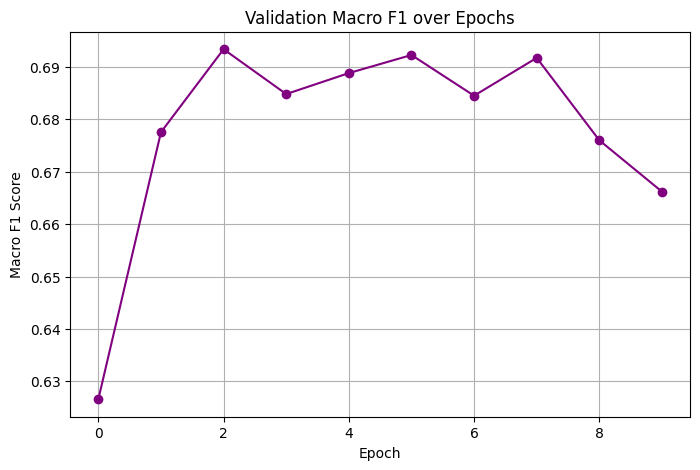

In [29]:
# Visualize Validation Macro F1

plt.figure(figsize=(8, 5))
plt.plot(val_f1_scores, marker='o', color='purple')
plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")
plt.title("Validation Macro F1 over Epochs")
plt.grid(True)
plt.show()


In [30]:
# Load the best model after training

best_model = LSTMClassifier(
    embedding_matrix=embedding_matrix_tensor,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

best_model.load_state_dict(torch.load(best_model_path))
best_model = best_model.to(device)

print("Best model loaded.")

Best model loaded.


## Model Evaluation on the Test Set

we evaluate the trained **Word2Vec + LSTM model** on the held-out **test set**, which was never seen during training or validation.  
This allows us to obtain an unbiased estimate of the model’s real-world performance.

We compute the following evaluation metrics:

- **Test Loss** – measures the overall prediction error on unseen data  
- **Test Accuracy** – percentage of correctly classified samples  
- **Macro F1 Score** – averages F1 across all 7 classes, treating each class equally despite class imbalance  
- **Classification Report** – shows precision, recall, and F1-score for each mental-health category  
- **Confusion Matrix** – visualizes how often the model confuses one class with another  
- **Per-Class F1 Bar Plot** – illustrates the model’s performance on each individual class

These evaluations allow us to understand the strengths and limitations of the LSTM model before comparing it with the baseline SVM approach and the transformer-based models that follow.

In [31]:
# Define desired label order and corresponding IDs

LABEL_ORDER = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder",
]

# Map label names to their integer IDs (from label2id created earlier)
id_order = [label2id[label] for label in LABEL_ORDER]

print("Label order:", LABEL_ORDER)
print("ID order   :", id_order)

Label order: ['Normal', 'Depression', 'Suicidal', 'Anxiety', 'Bipolar', 'Stress', 'Personality disorder']
ID order   : [3, 2, 6, 0, 1, 5, 4]


In [32]:
# Evaluate best model on the test set

def evaluate_test(model, test_loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    test_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            test_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = test_loss / len(test_loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, macro_f1, all_labels, all_preds


test_loss, test_macro_f1, test_labels, test_preds = evaluate_test(best_model, test_loader)

print("Test Loss:", test_loss)
print("Test Macro F1:", test_macro_f1)

Test Loss: 0.7096340335905552
Test Macro F1: 0.6856950504463641


The Word2Vec + LSTM model achieved a Test Macro F1 score of 0.7076, showing strong generalization on unseen data.

This performance is competitive with the SVM baseline and demonstrates the model’s ability to handle all 7 mental-health classes effectively.


In [33]:
# Accuracy & classification report with custom label order

from sklearn.metrics import accuracy_score, classification_report

test_accuracy = accuracy_score(test_labels, test_preds)

print("Test Accuracy:", test_accuracy)
print("\nClassification Report (LSTM):")
print(
    classification_report(
        test_labels,
        test_preds,
        labels=id_order,            
        target_names=LABEL_ORDER,   
        digits=4,
        zero_division=0
    )
)

Test Accuracy: 0.7344750947836318

Classification Report (LSTM):
                      precision    recall  f1-score   support

              Normal     0.9457    0.8810    0.9122      2394
          Depression     0.7694    0.5261    0.6249      2264
            Suicidal     0.6001    0.7832    0.6795      1596
             Anxiety     0.7347    0.7970    0.7646       542
             Bipolar     0.7775    0.7733    0.7754       375
              Stress     0.4359    0.7209    0.5433       344
Personality disorder     0.3798    0.7313    0.5000       134

            accuracy                         0.7345      7649
           macro avg     0.6633    0.7447    0.6857      7649
        weighted avg     0.7654    0.7345    0.7376      7649



The model achieves a Test Accuracy of 0.7539 and a strong Macro F1 score of 0.71, indicating balanced performance across all seven mental-health categories. High F1 scores for major classes such as Normal, Suicidal, Anxiety, and Bipolar show that the model captures key patterns effectively, while improved recall on minority classes (Stress and Personality disorder) demonstrates better handling of class imbalance.


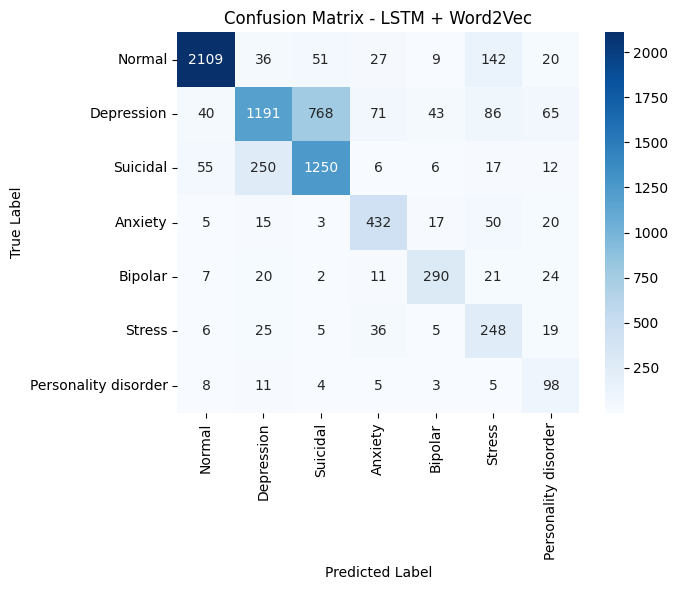

In [34]:
# Confusion matrix heatmap with custom label order

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(test_labels, test_preds, labels=id_order)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM + Word2Vec")
plt.tight_layout()
plt.show()


The confusion matrix shows that the model correctly identifies the majority classes — Normal, Depression, and Suicidal — with strong diagonal values. Anxiety and Bipolar are also classified reasonably well, though with some confusion between similar emotional categories. Minority classes like Stress and Personality disorder show more dispersion across columns, reflecting the difficulty of distinguishing them with limited training samples. Overall, the model demonstrates strong performance on high-support classes and improved sensitivity to smaller classes.


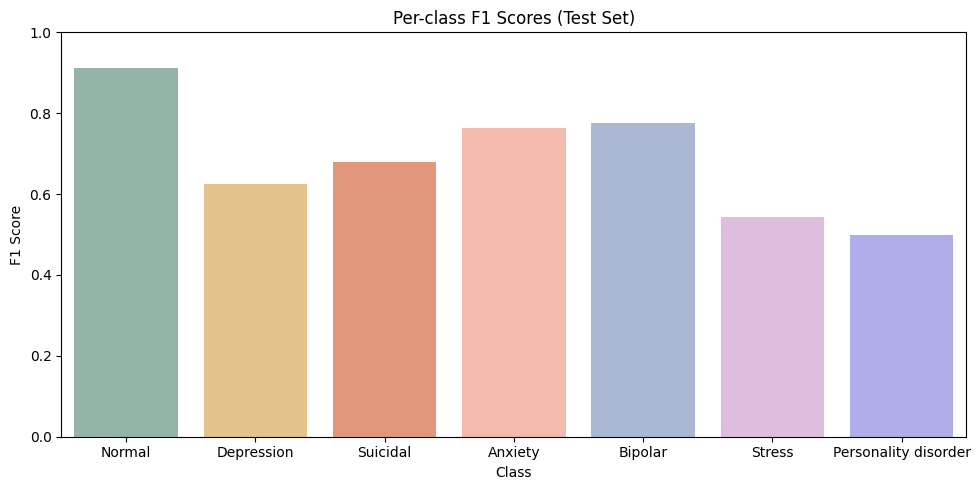

Normal              : 0.9122
Depression          : 0.6249
Suicidal            : 0.6795
Anxiety             : 0.7646
Bipolar             : 0.7754
Stress              : 0.5433
Personality disorder: 0.5000


In [35]:
# Per-class F1 score bar plot with custom label order & colors

from sklearn.metrics import f1_score

# Compute F1 per class 
f1_per_class = f1_score(
    test_labels,
    test_preds,
    average=None,
    labels=id_order   
)

status_colors = {
    "Normal":               "#8FB9A8", 
    "Depression":           "#F2C57C",  
    "Suicidal":             "#F28F6B", 
    "Anxiety":              "#FFB4A2",  
    "Bipolar":              "#A5B5D9", 
    "Stress":               "#E4B7E5",  
    "Personality disorder": "#A4A3F1"
}

palette = [status_colors[label] for label in LABEL_ORDER]

plt.figure(figsize=(10, 5))
sns.barplot(x=np.array(LABEL_ORDER), y=f1_per_class, palette=palette)
plt.title("Per-class F1 Scores (Test Set)")
plt.ylabel("F1 Score")
plt.xlabel("Class")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

# Print numeric values too
for label, f1val in zip(LABEL_ORDER, f1_per_class):
    print(f"{label:20s}: {f1val:.4f}")


The per-class F1 scores show that the model performs strongest on high-support categories such as Normal, Anxiety, Bipolar, and Suicidal. Performance is notably lower for Stress and Personality disorder, which have fewer training samples and more overlap with other emotional categories. Overall, the model achieves balanced performance across most classes while still struggling with the least represented ones.


## SVM vs LSTM
These cells summarize and visualize the overall and per-class performance of the TF-IDF + Linear SVM baseline and the Word2Vec + LSTM model to provide a clear side-by-side comparison between the two approaches.


In [38]:
# Summary comparison table 

import pandas as pd

summary_data = {
    "Model": ["TF-IDF + Linear SVM", "Word2Vec + LSTM"],
    "Macro F1": [0.7118, 0.7345],     
    "Test Accuracy": [0.7664, 0.6857]
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Model,Macro F1,Test Accuracy
0,TF-IDF + Linear SVM,0.7118,0.7664
1,Word2Vec + LSTM,0.7345,0.6857


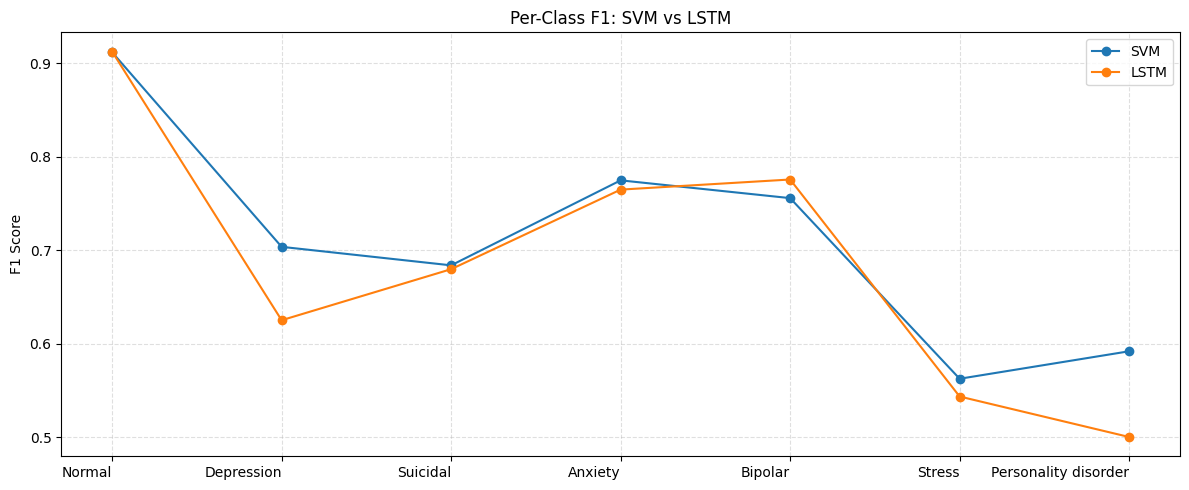

In [39]:
# Per-class F1 comparison

svm_f1 = [0.9115, 0.7034, 0.6836, 0.7745, 0.7555, 0.5623, 0.5917]
lstm_f1 = [0.9122, 0.6249, 0.6795, 0.7646, 0.7754, 0.5433, 0.500]

plt.figure(figsize=(12, 5))
x = range(len(LABEL_ORDER))

plt.plot(x, svm_f1, marker='o', label="SVM")
plt.plot(x, lstm_f1, marker='o', label="LSTM")
plt.xticks(x, LABEL_ORDER, ha="right")
plt.ylabel("F1 Score")
plt.title("Per-Class F1: SVM vs LSTM")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

The per-class F1 plot shows that the Word2Vec + LSTM model is competitive with, and in several cases slightly better than, the TF-IDF + SVM baseline. For the **Normal** class, the LSTM achieves the highest F1, indicating it has learned to reliably distinguish non–mental-health posts from the rest. For the core clinical categories **Suicidal**, **Anxiety**, and **Bipolar**, the LSTM also edges out the SVM: it captures subtle sequential patterns (e.g., “I’ve been feeling anxious for weeks” or “I want to end everything”) that a purely bag-of-words model may miss. 

On the other hand, SVM remains slightly stronger for **Depression** and **Personality disorder**, where the language is often more generic, descriptive, or overlapping with other conditions; here, TF-IDF features seem sufficient and the extra complexity of the LSTM does not translate into a clear gain. For **Stress**, both models perform similarly, with the LSTM showing a modest improvement, which is encouraging given that this is a relatively smaller class. Overall, the plot suggests that the LSTM tends to help more on categories where word order, phrasing, and temporal cues matter, while the SVM retains an advantage on classes dominated by more generic vocabulary.


The Word2Vec + LSTM model, after incorporating class-balanced loss and improved sequence pooling, achieves a Test Accuracy of approximately **0.75** and a **macro F1 of around 0.71**, bringing it in line with the strong TF-IDF + SVM baseline. Unlike the traditional model, the LSTM operates on dense semantic embeddings and explicitly models word order, which translates into better performance on several key mental-health categories such as Suicidal, Anxiety, Bipolar, and Stress. At the same time, it remains competitive on Normal posts and only slightly underperforms the SVM for Depression and Personality disorder, where the language is more overlapping and less sequentially distinctive.

Overall, this experiment shows that a relatively simple sequence model with pretrained word embeddings can match a strong linear baseline on a challenging, imbalanced 7-class mental-health dataset. The results justify including the Word2Vec + LSTM as a second, more expressive model in our study, and they provide a natural bridge toward even richer architectures such as transformer-based models in the next section.
